In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the fully processed graph
G = ox.load_graphml('../data/dc_subgraph_carbon.graphml')
print(f"Graph loaded: {len(G.nodes)} nodes, {len(G.edges)} edges")

Graph loaded: 960 nodes, 2186 edges


In [2]:
# We want to visualize the carbon intensity per meter to find 'dirty' roads
edge_colors = []
edge_linewidths = []

for u, v, k, data in G.edges(keys=True, data=True):
    # Intensity = carbon per meter
    length = float(data['length'])
    carbon = float(data['carbon_weight_rushhour'])
    intensity = carbon / length if length > 0 else 0
    
    # Append to color map
    edge_colors.append(intensity)
    
    # Thicker lines for main roads
    if 'highway' in data and data['highway'] in ['motorway', 'trunk', 'primary']:
        edge_linewidths.append(2.0)
    else:
        edge_linewidths.append(0.8)

/var/folders/00/3zxywg294fx03pyd7f783sqr0000gn/T/ipykernel_90983/2390666646.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno_r') # Red/Dark for high carbon, yellow for low


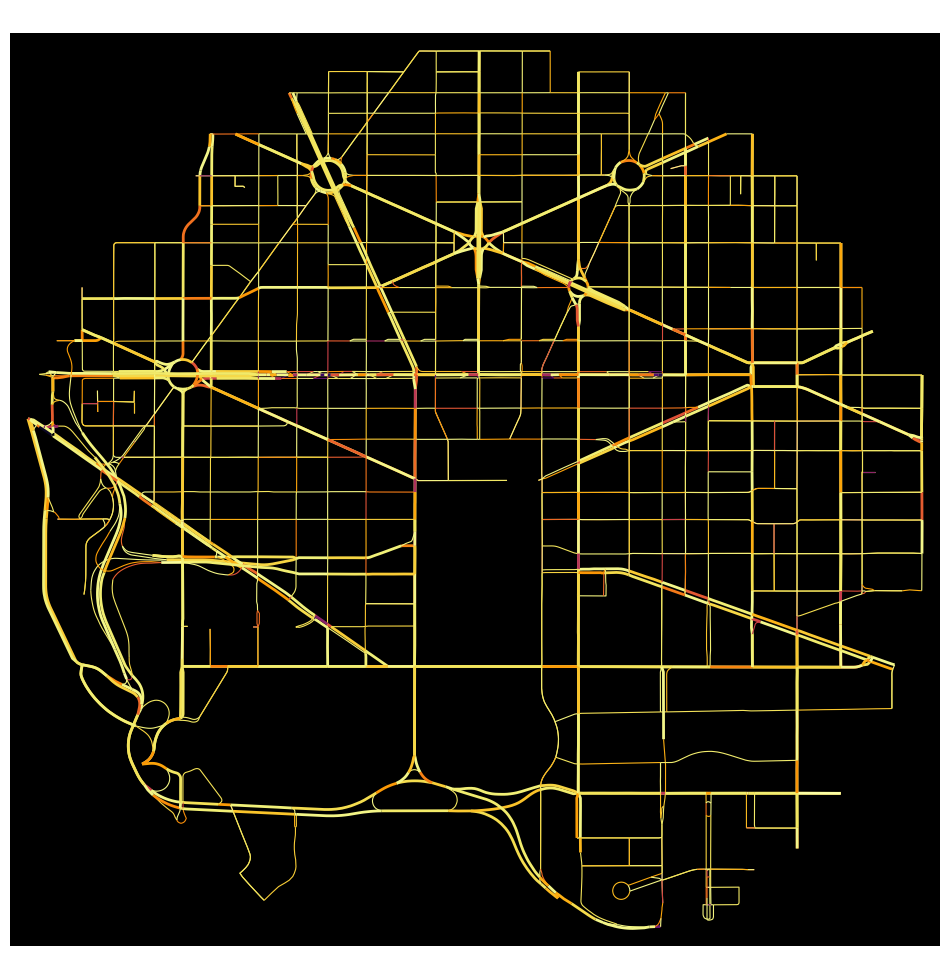

In [3]:
# Normalize colors to colormap
norm = mcolors.Normalize(vmin=min(edge_colors), vmax=max(edge_colors)*0.8) # Cap max for better contrast
cmap = cm.get_cmap('inferno_r') # Red/Dark for high carbon, yellow for low
colors = [cmap(norm(c)) for c in edge_colors]

fig, ax = ox.plot_graph(G, edge_color=colors, edge_linewidth=edge_linewidths, node_size=0, 
                        bgcolor='k', show=False, close=False, figsize=(12, 12))

ax.set_title('Carbon Weight Heatmap (g CO2e / meter) - Rush Hour D.C.', fontsize=16, color='white')
plt.savefig('../data/carbon_heatmap.png', dpi=300, bbox_inches='tight', facecolor='k')
plt.show()